In [1]:
import networkx as nx
import numpy as np 
import random
import utils

In [2]:
def random_er_dag(n, p):
    """
    Generate a random Erdos–Rényi DAG with n nodes and edge probability p.
    """
    G = nx.DiGraph()
    G.add_nodes_from(range(n))

    # Assign a random topological ordering of nodes
    nodes = list(range(n))
    random.shuffle(nodes)

    # Only allow edges from earlier to later in this ordering
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < p:
                G.add_edge(nodes[i], nodes[j])

    return G, nodes

In [3]:
G, order = random_er_dag(8, 0.3)
print("Nodes:", G.nodes())
print("Edges:", G.edges())
print("Is DAG?", nx.is_directed_acyclic_graph(G))

Nodes: [0, 1, 2, 3, 4, 5, 6, 7]
Edges: [(0, 6), (0, 4), (1, 6), (3, 6), (3, 2), (4, 2), (5, 6), (5, 2), (6, 4), (7, 1)]
Is DAG? True


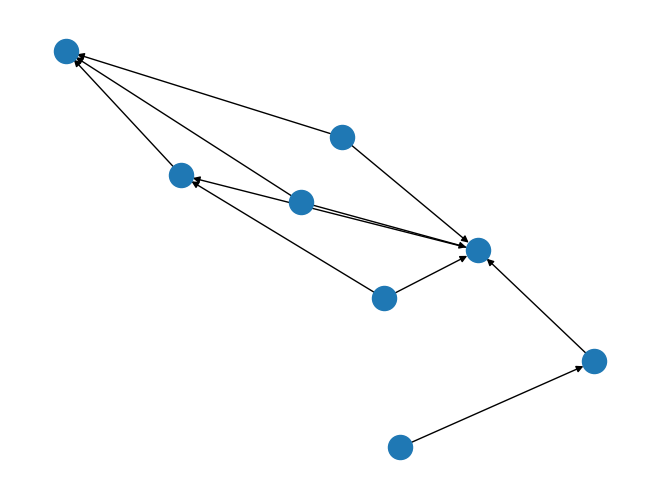

In [4]:
nx.draw(G)

In [5]:
A = nx.to_numpy_array(G)

In [6]:
A

array([[0., 0., 0., 0., 1., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.]])

In [7]:
nx.to_numpy_array(G, nodelist=order, dtype=int)

array([[0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0]])

In [8]:
def assign_weights(A): 
    
    r_weights = np.random.rand(A.shape[0],A.shape[1])
    
    return(np.multiply(A,r_weights))

    

In [9]:
W = assign_weights(A)


In [10]:
W

array([[0.        , 0.        , 0.        , 0.        , 0.97824178,
        0.        , 0.6776395 , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.62051944, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.6923666 , 0.        , 0.        ,
        0.        , 0.99621536, 0.        ],
       [0.        , 0.        , 0.98290323, 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.12012138, 0.        , 0.        ,
        0.        , 0.29627241, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.37678734,
        0.        , 0.        , 0.        ],
       [0.        , 0.61610515, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ]])

In [11]:
W.shape

(8, 8)

In [12]:
test_data = np.random.normal(size=(4, 8))
print("noise")
print(test_data)

print("data")
print(np.matmul(test_data, W))

print("weihts")
print(W)

noise
[[-1.18892006 -0.32026369  0.62679197 -0.53350307  0.79596168 -0.47184128
  -0.2686752  -0.06816465]
 [-1.20104406  0.30928547  0.46355559 -0.92419169  0.43695567  0.65038706
  -0.30164683 -1.08158823]
 [ 1.10369367  0.16582332 -0.44683597  0.39700295 -1.15060387 -1.77340152
   0.28285178 -0.34535968]
 [ 1.32815833  0.47710952 -0.70210201 -0.73140673 -1.79351099 -0.20734181
   0.15483541 -0.5112459 ]]
data
[[ 0.         -0.04199659  0.35629538  0.         -1.26428469  0.
  -1.67566656  0.        ]
 [ 0.         -0.66637208 -0.13226893  0.         -1.28856819  0.
  -1.34995947  0.        ]
 [ 0.         -0.21277788 -1.06908412  0.          1.18625422  0.
   0.72089352  0.        ]
 [ 0.         -0.31498123 -2.29415552  0.          1.35759999  0.
   0.40600001  0.        ]]
weihts
[[0.         0.         0.         0.         0.97824178 0.
  0.6776395  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.62051944 0.        ]
 [0.         0.         0.        

In [13]:
def gen_data(weights, n_samples):
    d_feats = weights.shape[0]
    data = np.ones(shape=(n_samples, d_feats))
    noise = np.random.normal(size=(n_samples, d_feats))

    return np.add(noise, np.matmul(data, weights))
    

In [14]:
G = utils.RandomGraph(10, 0.3)

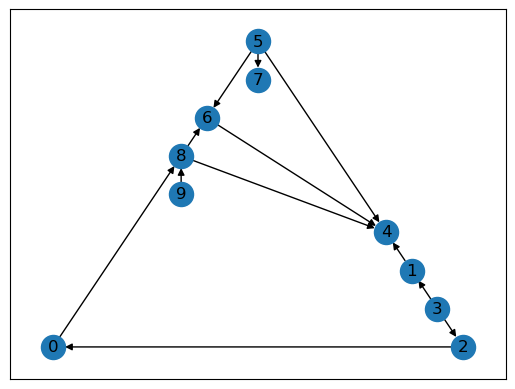

In [15]:
G.draw()

In [16]:
G.gen_data(10)

array([[ 0.7806651 ,  1.06252941, -0.52142029,  0.8766548 ,  1.5964019 ,
        -0.84678049,  1.4779813 ,  0.10566379,  1.36979523, -0.43852336],
       [-0.56228791,  0.59407895,  0.31958288,  0.73480543,  3.12104406,
        -1.88800511,  2.04564552, -0.63238246,  0.53896085,  1.33946952],
       [-0.96415618,  1.15434033,  0.21557149,  0.26681668,  1.7284084 ,
        -1.15903475,  2.57070836,  1.48667135,  2.22141809, -0.15599077],
       [-1.43252523,  1.09907201, -0.75869548,  0.56286273,  2.13678588,
         0.53083615,  1.26253279,  1.00082117, -0.13379972,  1.26770192],
       [ 0.80359943,  1.74427626, -0.67568084, -0.19747903,  2.90139539,
         0.35218318,  0.86640907, -0.43371158,  2.32645179,  1.64719819],
       [-1.42248705, -1.16721345,  0.43507537,  0.11104191,  0.25817083,
        -1.3707366 ,  1.27180785,  2.3090467 ,  1.32165641, -1.09091034],
       [ 0.70468487,  1.36265753, -1.45683721,  0.92153748,  2.48872873,
         0.15527446,  2.4081679 ,  0.7605308 

In [17]:
G.gen_data(1000)

array([[ 1.62175437,  0.90741694, -0.19136786, ..., -0.51236857,
         0.1827247 ,  0.14009543],
       [ 0.27322328,  1.66458648,  0.91624428, ...,  1.01677296,
         1.05490277, -0.30383922],
       [ 0.07302595, -0.08699656,  0.28908465, ...,  0.2803184 ,
         1.59002538, -0.85586211],
       ...,
       [ 1.13655416,  0.47575158,  1.29920432, ...,  0.93776113,
         0.13191777,  0.14973518],
       [ 1.99034953,  1.41140887, -0.08750365, ..., -1.09285431,
         1.01191282,  0.51065149],
       [ 0.33466743,  1.58890954, -0.92688805, ...,  2.2268432 ,
        -1.0393263 , -1.55664252]])

In [18]:
G.get_adj()

array([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 1., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]])

Experiment 4 Parameters 
- 3000 observations 
- 445 nodes 


In [19]:
sim_data = utils.RandomGraph(445, 0.3)

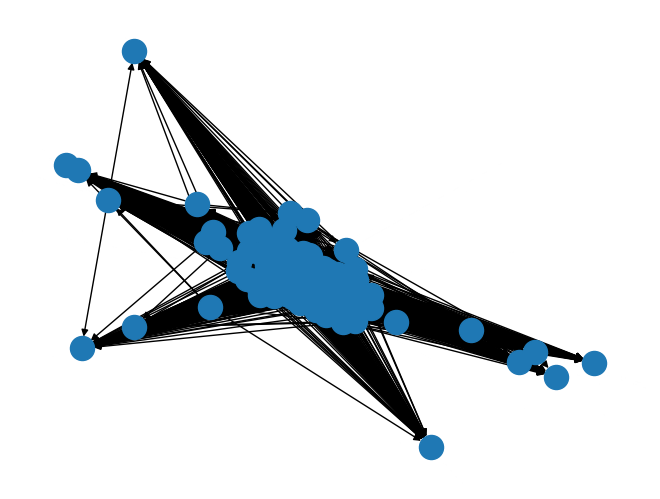

In [20]:
nx.draw(sim_data.G) 


In [21]:
df = sim_data.gen_data(3000)

In [ ]:
np.savetxt("experiment4_data.csv", df, delimiter=",")

In [24]:
np.savetxt("experiment4_true_adj.csv", sim_data.get_adj(), delimiter=",")